# EX7 — Speed profiling: the profile decides where you stop, the PID only follows it

**What you will see**
* A step setpoint asks for infinite acceleration: PWM slams to 255, the mouse overshoots the cell centre.
* A trapezoidal profile: accelerate → cruise → brake, with the **braking decision based on remaining distance**.
* The profile as a *moving setpoint* for the EX3 forward loop: stop error and peak PWM, step vs profile.
* Feed-forward: give the PID the PWM the profile speed will need anyway → the PID only corrects the residual.
* Bonus: time for a 6-cell straight vs `v_max` — the speed-run argument.

```
class Profile:
  start(d, v0, vmax, vend, a):   x_set = 0 ; v_set = v0
  update(dt):
    remaining = d - x_set
    if remaining <= (v_set² - vend²)/(2a):  v_set = max(v_set - a·dt, vend)   # brake
    elif v_set < vmax:                        v_set = min(v_set + a·dt, vmax)  # accelerate
    x_set += v_set·dt ; done = remaining <= 0

loop:  profile.update(dt);  target_counts = profile.x_set * counts_per_mm;  fwd = pid_fwd(target_counts - dist)
```

In [1]:
from mouse_sim import *

cfg = Config()
print(cfg.summary())

counts/rev = 360   counts/mm = 3.58   counts/cell = 645   counts/deg (L-R) = 5.00
passage = 168 mm   clearance per side = 34 mm   battery = 8.4 V / 8.4 V


## 1. Anatomy of the profile: 1, 3 and 6 cells at v_max = 0.5 m/s, a = 2 m/s²

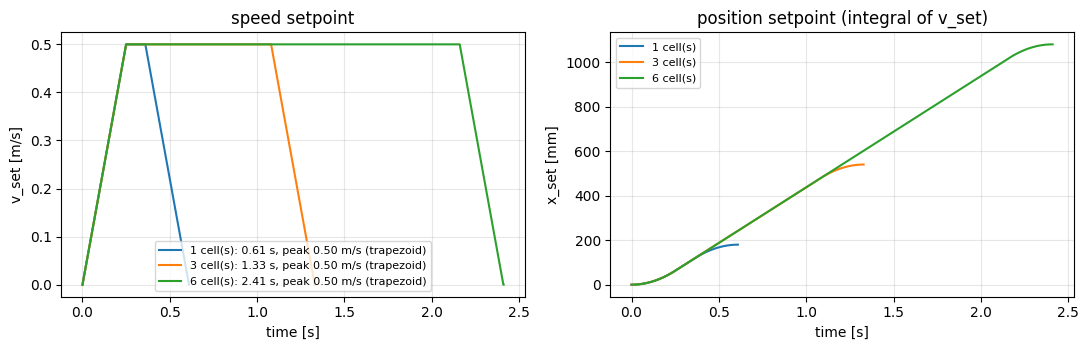

distance needed to reach 0.5 m/s at 2 m/s²: 62 mm accelerate + 62 mm brake
→ a 1-cell move (180 mm) just reaches v_max (55 mm of cruise); a half-cell (90 mm) cannot: v_peak = sqrt(a·d) = 0.42 m/s (triangle)


In [2]:
def make_profile(d, v0=0.0, vmax=0.5, vend=0.0, a=2.0, dt=cfg.dt):
    p = Profile(); p.start(d, v0, vmax, vend, a)
    t, v, x = [0.0], [v0], [0.0]
    while not p.done and t[-1] < 20:
        p.update(dt); t.append(t[-1] + dt); v.append(p.v_set); x.append(p.x_set)
    return np.array(t), np.array(v), np.array(x)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
for cells in (1, 3, 6):
    t, v, x = make_profile(cells * cfg.cell)
    shape = "triangle" if v.max() < 0.499 else "trapezoid"
    a1.plot(t, v, label=f"{cells} cell(s): {t[-1]:.2f} s, peak {v.max():.2f} m/s ({shape})")
    a2.plot(t, x * 1000, label=f"{cells} cell(s)")
a1.set_xlabel("time [s]"); a1.set_ylabel("v_set [m/s]"); a1.grid(alpha=0.3); a1.legend(fontsize=8); a1.set_title("speed setpoint")
a2.set_xlabel("time [s]"); a2.set_ylabel("x_set [mm]"); a2.grid(alpha=0.3); a2.legend(fontsize=8); a2.set_title("position setpoint (integral of v_set)")
fig.tight_layout(); savefig(fig, "ex07_profile_anatomy.png"); plt.show()

d_acc = 0.5 ** 2 / (2 * 2.0)
print(f"distance needed to reach 0.5 m/s at 2 m/s²: {d_acc*1000:.0f} mm accelerate + {d_acc*1000:.0f} mm brake")
print(f"→ a 1-cell move (180 mm) just reaches v_max ({180-2*d_acc*1000:.0f} mm of cruise); a half-cell (90 mm) cannot: v_peak = sqrt(a·d) = {math.sqrt(2.0*0.09):.2f} m/s (triangle)")

**Talking points**
* `d_acc = v²/(2a)` = 62 mm at these numbers: below 125 mm of travel the profile never reaches `v_max` (triangle);
  a full cell just makes it.
* Braking starts when `remaining ≤ (v² − v_end²)/(2a)`. Distance-based, so timing errors do not accumulate.
* `v_end` is a parameter from day one: later, smooth turns need `v_end ≠ 0`.

## 2. Step vs profile on the (simulated) mouse — the EX3 forward loop
Both use the same forward PID (Kp = 3, Kd = 0.15, tuned in EX6). Only the setpoint differs.

One piece of realism is added: **traction**. Motor torque is proportional to the speed error inside the motor;
when that demand exceeds a limit (≈ 6 m/s² of asked-for acceleration here) the tyres slip, up to 30 %.
Slip means the wheel turns more than the mouse moves — the encoders over-count and the mouse stops **short**
while believing it arrived. This is the crude version of what every real mouse does on a PWM slam.

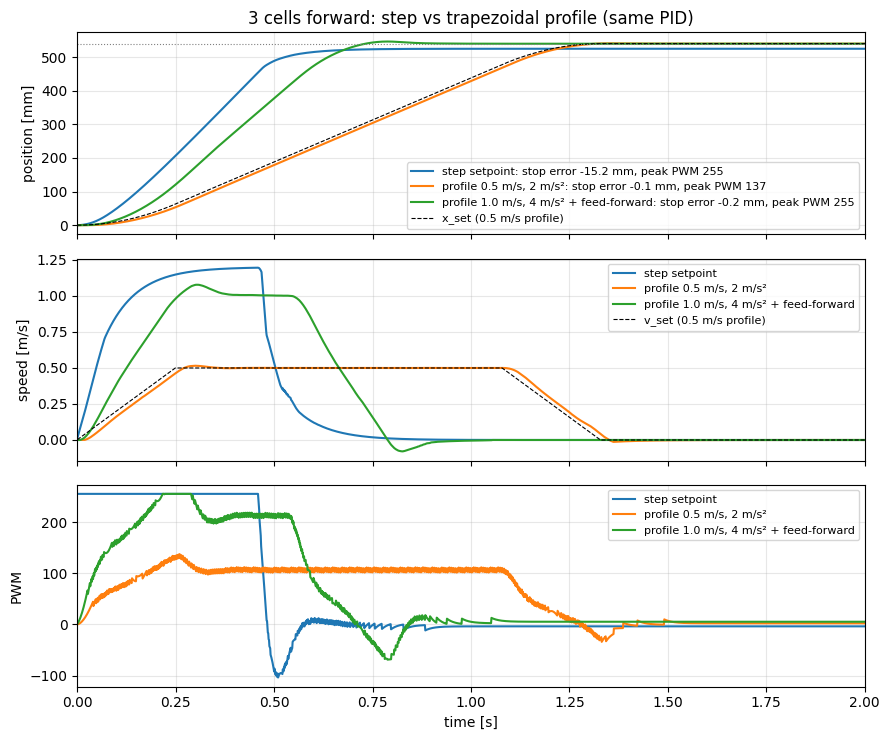

In [3]:
def run_move(cfg, cells=3, mode="profile", vmax=0.5, a=2.0, kp=3.0, kd=0.15, ki=0.0,
             kff=0.0, t_max=3.0, tf=0.02):
    """mode: 'step' (target jumps to the goal), 'profile' (moving setpoint), 'profile+ff' (adds feed-forward).
    kff: PWM per (m/s) of v_set — the open-loop PWM the motor needs to hold that speed."""
    m = DiffDrive(cfg, traction_dv=0.5, slip_max=0.30)
    pid = PID(kp, ki, kd, tf=tf, umin=-255, umax=255)
    goal_m = cells * cfg.cell
    prof = Profile(); prof.start(goal_m, 0.0, vmax, 0.0, a)
    n = int(t_max / cfg.dt)
    t = np.arange(n) * cfg.dt
    log = {k: np.zeros(n) for k in ("x", "x_set", "v", "v_set", "pwm")}
    for i in range(n):
        cL, cR = m.counts
        dist = (cL + cR) / 2
        if mode == "step":
            x_set, v_set = goal_m, 0.0
        else:
            prof.update(cfg.dt); x_set, v_set = prof.x_set, prof.v_set
        u = pid.update(x_set * cfg.counts_per_m - dist, cfg.dt)
        if mode == "profile+ff":
            u += kff * v_set
        u = max(-255, min(255, u))
        m.step(u, u)
        for k, val in zip(log, (m.x, x_set, m.v, v_set, u)):
            log[k][i] = val
    return t, log


def stop_error_mm(log, cells):
    """where the mouse REALLY stopped relative to the goal (the encoders think it is at the goal)."""
    return (log["x"][-1] - cells * cfg.cell) * 1000

kff = 255 / cfg.km        # PWM needed per m/s at full battery (from EX1's model: 1.2 m/s at PWM 255)
runs = {
    "step setpoint": run_move(cfg, mode="step"),
    "profile 0.5 m/s, 2 m/s²": run_move(cfg, mode="profile"),
    "profile 1.0 m/s, 4 m/s² + feed-forward": run_move(cfg, mode="profile+ff", kff=kff, vmax=1.0, a=4.0),
}
fig, axes = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
for lab, (t, L) in runs.items():
    axes[0].plot(t, L["x"] * 1000, label=f"{lab}: stop error {stop_error_mm(L, 3):+.1f} mm, peak PWM {abs(L['pwm']).max():.0f}")
    axes[1].plot(t, L["v"], label=lab)
    axes[2].plot(t, L["pwm"], label=lab)
t, L = runs["profile 0.5 m/s, 2 m/s²"]
axes[0].plot(t, L["x_set"] * 1000, "k--", lw=0.8, label="x_set (0.5 m/s profile)"); axes[1].plot(t, L["v_set"], "k--", lw=0.8, label="v_set (0.5 m/s profile)")
axes[0].axhline(3 * cfg.cell * 1000, color="0.5", ls=":", lw=0.8)
axes[0].set_ylabel("position [mm]"); axes[1].set_ylabel("speed [m/s]"); axes[2].set_ylabel("PWM"); axes[2].set_xlabel("time [s]")
for ax in axes: ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="best")
axes[0].set_xlim(0, 2.0); axes[0].set_title("3 cells forward: step vs trapezoidal profile (same PID)")
fig.tight_layout(); savefig(fig, "ex07_step_vs_profile.png"); plt.show()

### Feed-forward
- **Feed-forward:** instead of waiting for an error to build up and letting the PID push against it,
  add the PWM you *already know* the target speed will need (`kff × v_set`) straight into the output —
  a prediction, not a reaction.
- **`kff = 255/cfg.km`:** "how much PWM does 1 m/s actually need, on average" — measured once from the motor's own top-speed number, then reused as a constant.  
- **Effect on the plot:** the green PWM trace reaches its cruise level almost instantly and stays flat and
  small — the PID's own contribution is now just a small trim on top, because feed-forward is already
  supplying most of the effort.

**Talking points**
* Step: PWM at 255 for the whole run, the tyres slip, the encoders over-count → the mouse stops **short** of the
  cell centre while the controller reports "arrived". In a maze that is a turn started in the wrong place.
* Profile at 0.5 m/s: PWM stays under the traction limit, the stop is exact. Slower — because we *chose* an
  exploration speed.
* Profile at 1.0 m/s with feed-forward: as fast as the step, still exact. The PID output is small because the
  feed-forward supplies the PWM the speed needs; the loop only corrects the residual.

## 3. Zoom on the arrival

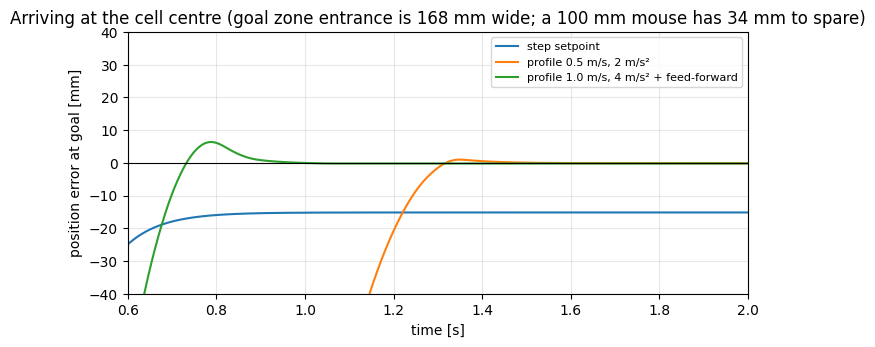

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.4))
for lab, (t, L) in runs.items():
    ax.plot(t, (L["x"] - 3 * cfg.cell) * 1000, label=lab)
ax.axhline(0, color="k", lw=0.8); ax.set_ylim(-40, 40); ax.set_xlim(0.6, 2.0)
ax.set_xlabel("time [s]"); ax.set_ylabel("position error at goal [mm]"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("Arriving at the cell centre (goal zone entrance is 168 mm wide; a 100 mm mouse has 34 mm to spare)")
savefig(fig, "ex07_arrival_zoom.png"); plt.show()

Same three runs, just re-plotted zoomed in on the last 40 mm around the goal — makes the step run's
overshoot/short-stop visible against the real physical tolerance (168 mm gap, 100 mm mouse → 34 mm to
spare either side).

## EX7 — the few points that matter most

1. **A profile is just a moving target.** It doesn't replace the PID from EX3 — it feeds the *same*
   forward PID a setpoint that changes every tick instead of jumping straight to the goal.

2. **Braking is decided by remaining distance, not time.** `remaining ≤ (v² − v_end²)/(2a)` — this is the
   one line that matters; get it wrong and the mouse either brakes too early/late or never stops cleanly.

3. **A step setpoint looks fine on paper but lies in practice.** PWM slams to max → tyres slip → encoders
   over-count → the mouse physically stops **short** while reporting "arrived." That's a real failure
   mode, not a hypothetical one.

4. **The profile fixes it by staying under the traction limit** — slower, but the stop is exact.

5. **Feed-forward gets speed back without losing accuracy.** Add the PWM the target speed already needs
   (`kff × v_set`) so the PID only has to correct the small leftover error — as fast as the step, but
   still exact.

6. **Above ~1 m/s, acceleration matters more than top speed.** Past that point the mouse spends most of
   the distance speeding up/slowing down, not cruising — so acceleration is the real lever for a fast run.

**One-line summary:** *"The profile decides where you should be right now; the PID's only job is to get
you there — and feed-forward is what lets it do that without a fight."*

## 4. Bonus: why speed runs exist — time for a 6-cell straight vs v_max

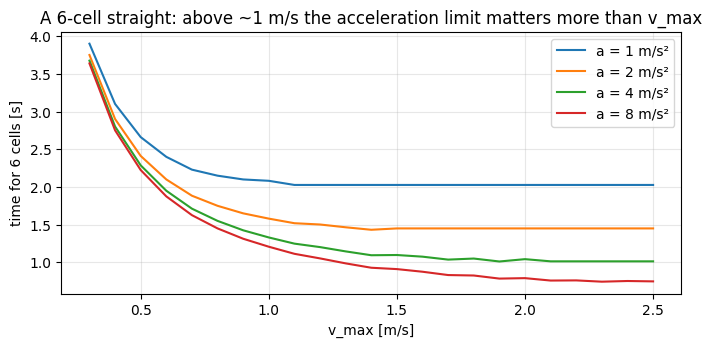

In [5]:
vms = np.linspace(0.3, 2.5, 23)
fig, ax = plt.subplots(figsize=(8, 3.4))
for a in (1.0, 2.0, 4.0, 8.0):
    times = [make_profile(6 * cfg.cell, vmax=v, a=a)[0][-1] for v in vms]
    ax.plot(vms, times, label=f"a = {a:.0f} m/s²")
ax.set_xlabel("v_max [m/s]"); ax.set_ylabel("time for 6 cells [s]"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("A 6-cell straight: above ~1 m/s the acceleration limit matters more than v_max")
savefig(fig, "ex07_time_vs_vmax.png"); plt.show()

**Talking point:** exploration at 0.3–0.5 m/s is fine; the speed run's gains come from acceleration and from not
stopping at every cell (smooth turns, `v_end ≠ 0`) — that is the Part-3 story.

## Try this
* `a=6.0` in `run_move(...)` — the profile asks for more than the motor can give; PWM saturates and it behaves like the step again.
* `cells=1` — triangle profile; compare stop errors.
* `v_batt=6.6` in `cfg` with the same `kff` — feed-forward is now wrong by 20 %; the PID has to cover it (EX6 battery scaling).

## On your mouse
* `x_set` must be integrated from `v_set` every tick; feed `x_set × counts_per_mm` to the same forward PID as EX3.
* Braking distance from *remaining distance*, never from elapsed time.
* The same class turns with degrees (EX5). Keep the units consistent per instance.
* Feed-forward PWM per (m/s) = 255 / (rim speed at PWM 255) — measure it once with an open-loop run (EX1 style).